Jumlah awal: 6125
Jumlah setelah cleaning: 5280
Jumlah titik: 5280
Jumlah label: 5280


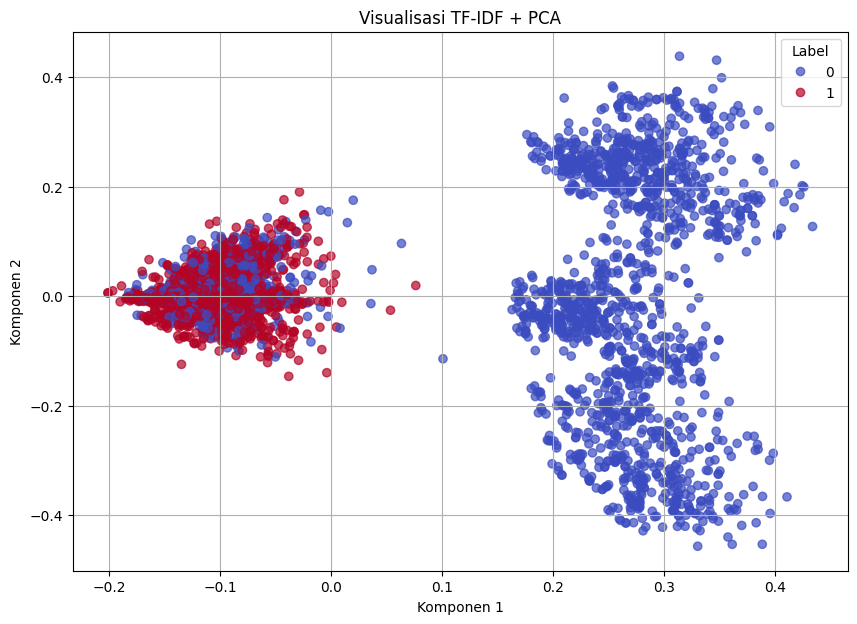

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# ============================================================
# 1. LOAD DATASET
# ============================================================
df = pd.read_csv("../data/raw/dataset_gabungan.csv")

print("Jumlah awal:", len(df))

# ============================================================
# 2. ENCODE LABEL
# ============================================================
df['label_num'] = df['label'].map({
    'hoax': 1,
    'fakta': 0,
    'valid': 0
})

# 🔥 BUANG DATA INVALID
df = df.dropna(subset=['label_num']).reset_index(drop=True)

print("Jumlah setelah cleaning:", len(df))

# ============================================================
# 3. AMBIL TEKS (SETELAH CLEANING!)
# ============================================================
texts = df['tweet'].astype(str)

# ============================================================
# 4. TF-IDF
# ============================================================
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts)

# ============================================================
# 5. PCA
# ============================================================
X_dense = X.toarray()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# ============================================================
# 6. CEK KESESUAIAN (DEBUG)
# ============================================================
print("Jumlah titik:", X_pca.shape[0])
print("Jumlah label:", len(df['label_num']))

# ============================================================
# 7. VISUALISASI
# ============================================================
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['label_num'],
    cmap='coolwarm',
    alpha=0.7
)

plt.title("Visualisasi TF-IDF + PCA")
plt.xlabel("Komponen 1")
plt.ylabel("Komponen 2")

plt.legend(*scatter.legend_elements(), title="Label")
plt.grid(True)

plt.savefig("../gambar/vsm_pca_final.png", dpi=300)
plt.show()

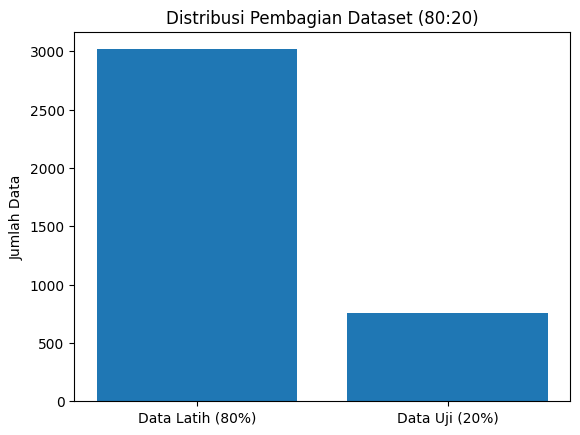

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("../data/raw/dataset_gabungan.csv")

# Ambil hanya label valid
df = df[df['label'].isin(['hoax', 'valid'])]

# Split 80:20
X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hitung jumlah
train_size = len(X_train)
test_size = len(X_test)

# Plot
plt.figure()
plt.bar(["Data Latih (80%)", "Data Uji (20%)"], [train_size, test_size])
plt.title("Distribusi Pembagian Dataset (80:20)")
plt.ylabel("Jumlah Data")

# Simpan
plt.savefig("../gambar/split_80_20.png")
plt.show()

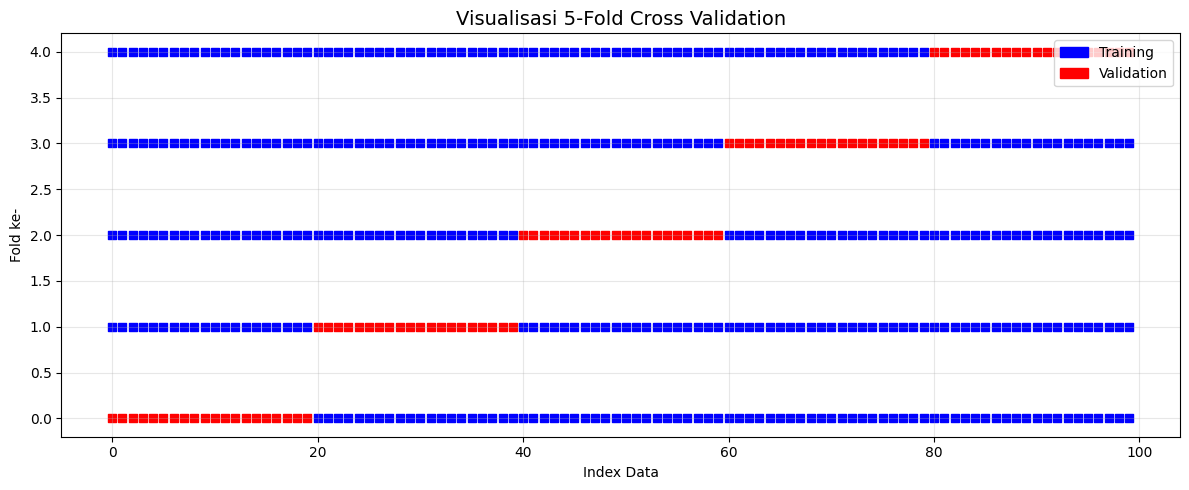

In [10]:
import matplotlib.pyplot as plt
import numpy as np

n_samples = 100
k = 5
indices = np.arange(n_samples)

fold_size = n_samples // k

plt.figure(figsize=(12, 5))

for i in range(k):
    start = i * fold_size
    end = start + fold_size

    for j in indices:
        if start <= j < end:
            # 🔴 VALIDATION
            plt.scatter(j, i, color='red', marker='s', s=30)
        else:
            # 🔵 TRAINING
            plt.scatter(j, i, color='blue', marker='s', s=30)

plt.title("Visualisasi 5-Fold Cross Validation", fontsize=14)
plt.xlabel("Index Data")
plt.ylabel("Fold ke-")

# Legend
import matplotlib.patches as mpatches
train_patch = mpatches.Patch(color='blue', label='Training')
val_patch = mpatches.Patch(color='red', label='Validation')

plt.legend(handles=[train_patch, val_patch])

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../gambar/kfold_final.png", dpi=300)
plt.show()